## Orbita3d assembly test code

- connecting to the orbita2d + executing the movement in two axis
- measuign  and checking the torque

### Launch the EtherCAT sever

In [5]:
from poulpe_ethercat_py import PyEthercatServer
import time

# launch the server
server = PyEthercatServer()
server.launch_server("../../config/ethercat.yaml")
time.sleep(1)

# print all slaves in the network
devices = server.get_all_slaves_in_network()
print("Devices connected in the network: ")
for i,name in zip(devices[0],devices[1]):
    print("Slave {}: {}".format(i,name))

POULPE controller ready!
Devices connected in the network: 
Slave 0: LeftWristOrbita3d


### Create teh  the EtherCAT sever

In [6]:
from poulpe_ethercat_py import PyPoulpeRemoteClient

slave_id = 0
n_axis =  3# 2 or 3

# Create an instance of the client
client = PyPoulpeRemoteClient(server.addr, [slave_id], 0.001)

print(client.get_connected_devices())

## turn of the orbita
client.turn_off(slave_id)
# set the mode of operation to position
time.sleep(0.5)
client.set_mode_of_operation(slave_id, 1) # set position mode
time.sleep(0.5)
## turn of the orbita
client.turn_on(slave_id)
# set the velocity and torque limits 
client.set_torque_limit(slave_id,[1.0]*n_axis)
client.set_velocity_limit(slave_id, [1.0]*n_axis)

([0], ['LeftWristOrbita3d'])


### Execute the movement

In [8]:
import numpy as np
import time


client.set_torque_limit(slave_id,[1.0]*n_axis)
client.set_velocity_limit(slave_id, [1.0]*n_axis)

t0 = time.time()
stop = False
tar, t=[],[]
pos, vel, torque, axis_sensors = [], [], [], []
target = 0

while target < 5.3333333*2*np.pi:
    target = target+0.004
    client.set_target_position(slave_id,[target]*n_axis)
    time.sleep(0.001)
    t.append(time.time()-t0)
    tar.append(client.get_target_position(slave_id))
    pos.append(client.get_position_actual_value(slave_id))
    vel.append(client.get_velocity_actual_value(slave_id))
    torque.append(client.get_torque_actual_value(slave_id))
    axis_sensors.append(client.get_axis_sensors(slave_id))

print("Rotate back to 0 degrees")
while target > 0:
    target = target-0.004
    client.set_target_position(slave_id,[target]*n_axis)
    time.sleep(0.001)
    t.append(time.time()-t0)
    tar.append(client.get_target_position(slave_id))
    pos.append(client.get_position_actual_value(slave_id))
    vel.append(client.get_velocity_actual_value(slave_id))
    torque.append(client.get_torque_actual_value(slave_id))
    axis_sensors.append(client.get_axis_sensors(slave_id))
        
tar = np.array(tar)
vel = np.array(vel)
pos = np.array(pos)
torque = np.array(torque)
axis_sensors = np.array(axis_sensors)
client.set_torque_limit(slave_id,[0.3]*n_axis)
client.set_velocity_limit(slave_id, [0.3]*n_axis)
client.set_target_position(slave_id,[0]*n_axis)

Rotate back to 0 degrees


### Plot the movement

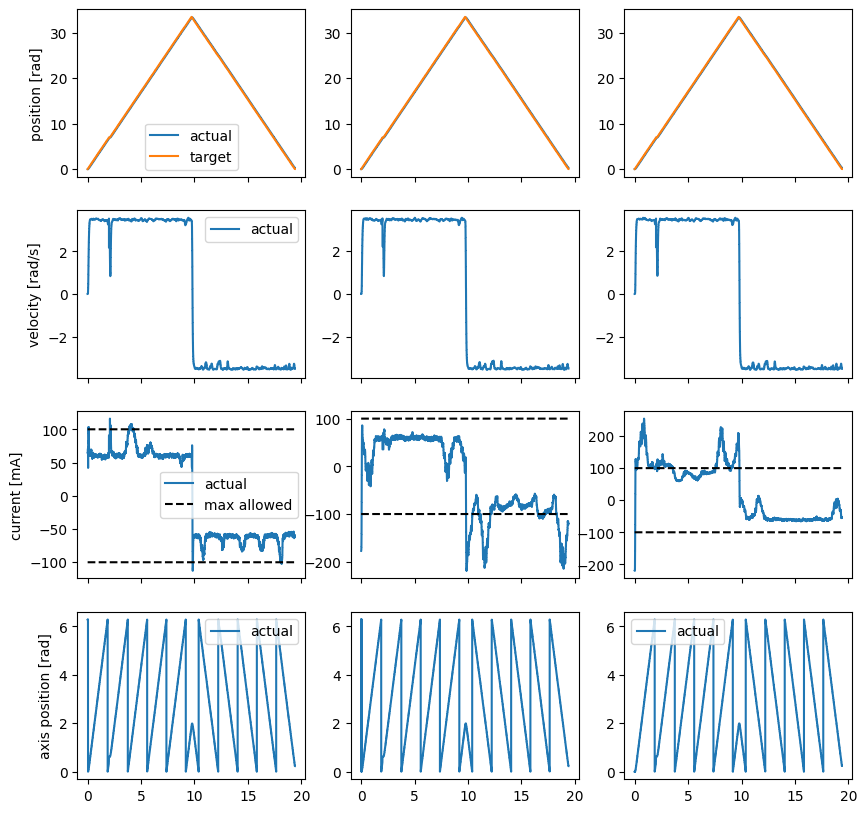

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axs = plt.subplots(4,n_axis, figsize=(10,10), sharex=True)

for i, a in enumerate(axs.T):
    a[0].step(t,pos[:,i], label="actual")
    a[0].step(t,tar[:,i], label="target")    
    a[1].step(t,vel[:,i], label = "actual")
    a[2].step(t,torque[:,i], label = "actual")
    a[2].step(t,np.ones_like(t)*100, "k--", label="max allowed")
    a[2].step(t,-np.ones_like(t)*100, "k--")
    a[3].step(t, axis_sensors[:,i], label = "actual")

for i, a in enumerate(axs[:].T):
    a[0].set_ylabel("position [rad]")
    a[0].legend()
    a[1].set_ylabel("velocity [rad/s]")
    a[1].legend()
    a[2].set_ylabel("current [mA]")
    a[2].legend()
    a[3].set_ylabel("axis position [rad]")
    a[3].legend()
    break

plt.legend()